## Imports

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob

from pyproj import Transformer
import pykrige.kriging_tools as kt
from pykrige.ok import OrdinaryKriging


## Helper Functions
Utilities for depth-averaging borehole measurements and loading drainage basin geometries.

In [11]:
def depth_average(depth, vals):
    return np.trapz(vals, depth) / (depth[-1] - depth[0])

def load_drainage_basins(drainage_dir, percent=10):
    drainage_files = glob.glob(f"{drainage_dir}*.exp")
    print("Found drainage basin files:", drainage_files)
    drainage_data = []
    for filename in drainage_files:
        print(" Loading drainage basin data from file:", filename)
        data = np.loadtxt(filename, skiprows=5)
        n = len(data)
        subsample_indices = np.random.choice(n, size=int(n * percent / 100), replace=False)
        subsampled_data = data[subsample_indices]
        drainage_data.append(subsampled_data)
    return drainage_data

## Kriging Interpolation
Loads borehole conductivity data, fits an Ordinary Kriging model, and optionally plots the interpolated field over Antarctic drainage basins.

To run, change data_dir to: https://source.coop/englacial/ice-sheet-temperature/AntarcticaBoreholeData

In [12]:
def query_kriging_conductivity(
    query_lat,
    query_lon,
    data_dir="../AntarcticaBoreholeData/", # change to: https://source.coop/englacial/ice-sheet-temperature/AntarcticaBoreholeData
    drainage_dir="../Rignot-drainage-basins/",
    plot=True
):
    transformer = Transformer.from_crs("EPSG:4326", "EPSG:3031")

    # load drainage basin data. You can replace this with your own. 
    drainage_data = load_drainage_basins(drainage_dir, percent=50)

    # load borehole meta data
    loc_file = "BoreholeLocations.csv"
    loc_data = pd.read_csv(f"{data_dir}/{loc_file}")
    # load borehole specific data (only with the impurity files in subdirs)
    imp_files = glob.glob(f"{data_dir}/**/*_imp.csv", recursive=True)

    # collect data into a dictionary
    conduc_dict = {}
    for filename in imp_files:
        sample_name = filename.split("/")[-1].split("_")[0]
        entry_name_lc = loc_data["Name"].str.lower()
        if sample_name.lower() in entry_name_lc.values:
            entry_index = entry_name_lc[entry_name_lc == sample_name.lower()].index[0]
            entry = loc_data.iloc[entry_index]
            print("Entry found for sample:", sample_name)
            imp_data = pd.read_csv(filename)

            depth_col = [col for col in imp_data.columns if "depth" in col.lower()]
            conduc_col = [col for col in imp_data.columns if "conductivity_inf" in col.lower()]
            print("----- depth column name:", depth_col)
            print("----- conductivity column name:", conduc_col)

            if depth_col and conduc_col:
                depth = imp_data[depth_col[0]].values
                conductivity = imp_data[conduc_col[0]].values
                avg_conductivity = depth_average(depth, conductivity)
                depth_computed = [depth[0], depth[-1]]
                depth_borehole = entry["Drilled Depth"]
                print("----- Average conductivity for sample", sample_name, ":", avg_conductivity)
                print("----- Depth computed for sample", sample_name, ":", depth_computed)
                print("----- Depth borehole for sample", sample_name, ":", depth_borehole)
            else:
                print("----- Depth or conductivity_inf column not found for sample:", sample_name)

            conduc_dict[sample_name] = {
                "latitude": entry["Lat"],
                "longitude": entry["Lon"],
                "avg_conductivity": avg_conductivity,
                "depth_computed": depth_computed,
                "depth_borehole": depth_borehole
            }
        else:
            print("No entry found for sample:", sample_name)
            
    # build the array for kriging
    x, y, z = [], [], []
    for sample_name, sample_data in conduc_dict.items():
        x_coord, y_coord = transformer.transform(sample_data["latitude"], sample_data["longitude"])
        x.append(x_coord)
        y.append(y_coord)
        z.append(sample_data["avg_conductivity"])

    data_matrix = np.array([x, y, z]).T
    print("borehole data:", data_matrix)
    # krigging object
    OK = OrdinaryKriging(
        data_matrix[:, 0],
        data_matrix[:, 1],
        data_matrix[:, 2],
        variogram_model="linear",
        verbose=False,
        enable_plotting=False,
    )
    # assuming input point is in lat lon
    query_x, query_y = transformer.transform(query_lat, query_lon)
    z_pred, _ = OK.execute("points", np.array([query_x]), np.array([query_y]))
    query_value = float(z_pred[0])
    print(f"Kriging value at ({query_lat}, {query_lon}): {query_value}")

    if plot:
        # plot domain 
        xmin, xmax = -3000000, 3000000
        ymin, ymax = -3000000, 3000000
        gridx = np.linspace(xmin, xmax, 500)
        gridy = np.linspace(ymin, ymax, 500)

        # kriging
        z_grid, ss_grid = OK.execute("grid", gridx, gridy)

        plt.figure(figsize=(10, 8))
        plt.imshow(z_grid, extent=(xmin/1e3, xmax/1e3, ymin/1e3, ymax/1e3), origin="lower")
        plt.colorbar(label="Average Conductivity (S/m)")

        for basin in drainage_data:
            plt.scatter(basin[:, 0]/1e3, basin[:, 1]/1e3, s=1, color="w", alpha=0.5)

        # add known borehold data
        for sample_name, sample_data in conduc_dict.items():
            x_coord, y_coord = transformer.transform(sample_data["latitude"], sample_data["longitude"])
            plt.scatter(x_coord/1e3, y_coord/1e3, s=50, color="red", marker="x")
            plt.text(x_coord/1e3, y_coord/1e3, sample_name, fontsize=8, ha="right", va="bottom")
        # add query point
        plt.scatter(query_x/1e3, query_y/1e3, s=100, color="yellow", marker="*", label="Query point")
        plt.legend()
        plt.xlabel("X (km)")
        plt.ylabel("Y (km)")
        plt.title("Kriging Interpolation of Average Conductivity with Drainage Basins")
        plt.show()

    return query_value

## Run Query
Predict average conductivity at a given lat/lon point using the kriging model.

Found drainage basin files: ['../Rignot-drainage-basins/I-Ipp.exp', '../Rignot-drainage-basins/Ipp-J.exp', '../Rignot-drainage-basins/G-H.exp', '../Rignot-drainage-basins/J-Jpp.exp', '../Rignot-drainage-basins/A-Ap.exp', '../Rignot-drainage-basins/K-A.exp', '../Rignot-drainage-basins/Islands.exp', '../Rignot-drainage-basins/Dp-E.exp', '../Rignot-drainage-basins/D-Dp.exp', '../Rignot-drainage-basins/H-Hp.exp', '../Rignot-drainage-basins/Jpp-K.exp', '../Rignot-drainage-basins/F-G.exp', '../Rignot-drainage-basins/Ep-F.exp', '../Rignot-drainage-basins/B-C.exp', '../Rignot-drainage-basins/Hp-I.exp', '../Rignot-drainage-basins/Cp-D.exp', '../Rignot-drainage-basins/C-Cp.exp', '../Rignot-drainage-basins/E-Ep.exp', '../Rignot-drainage-basins/Ap-B.exp']
 Loading drainage basin data from file: ../Rignot-drainage-basins/I-Ipp.exp
 Loading drainage basin data from file: ../Rignot-drainage-basins/Ipp-J.exp
 Loading drainage basin data from file: ../Rignot-drainage-basins/G-H.exp
 Loading drainage ba

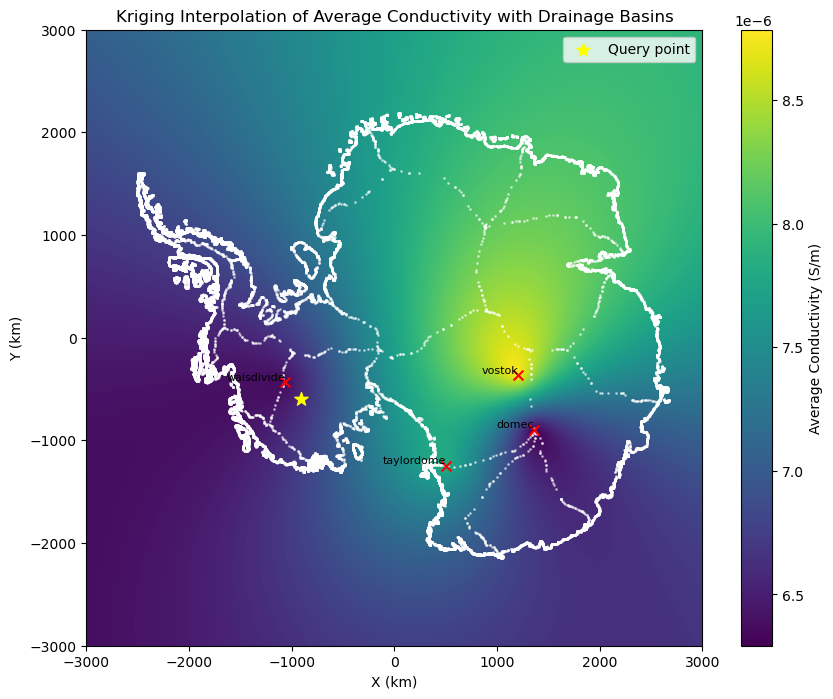

Predicted average conductivity at (-80.0, -123.0): 6.587111882304728e-06 S/m


In [13]:
query_lat = -80.0
query_lon = -123.0
conductivity_value = query_kriging_conductivity(query_lat, query_lon)
print(f"Predicted average conductivity at ({query_lat}, {query_lon}): {conductivity_value} S/m")